# Case 0

# How much does dataset scale affect false-positive calibration comparisons?

## Purpose of this notebook

This notebook demonstrates something case01 depends on but doesn't show directly: **the false-positive-rate ordering across architectures is not stable across dataset scale** — the same four-architecture clean-baseline comparison can give a *different, sometimes opposite* ranking depending on how much warmup data each model gets.

This isn't a hypothetical concern. Running case01's own comparison on a mini (~17-year warmup) slice versus the full-scale (34.5-year warmup) export produced opposite conclusions about which architecture is best-calibrated — discovered while validating case01 itself. This notebook reproduces that finding directly, side by side, in one place.

---

## What is being compared?

This notebook does not define a new experiment. It runs **case01's own suite** (`case01_clean_baseline_suite.yaml`) at three dataset scales — `DATA_SOURCE = "mini_28pct"`, `"mini_50pct"`, and `"full_split_files"` — and compares the results directly:

| Variant | Architecture | Meaning |
|---|---|---|
| **MLP-VAE** | Feed-forward VAE, plain (no cyclic reconstruction) | thesis_code's baseline MLP. |
| **MLP-VAE-Cyclic** | Feed-forward VAE, cyclic time features reconstructed | The thesis found this stays calibrated from the very first test-stream step. |
| **LSTM-VAE** | Recurrent VAE | Sits between the MLP and Transformer variants in capacity. |
| **Transformer-VAE** | Attention-based VAE | The thesis found this overfits the warmup window and produces an early false-positive burst before its rolling threshold adapts. |

See `case01_clean_baseline.ipynb` for architecture details — this notebook focuses on how the *comparison itself* changes with dataset scale, not on the architectures individually.

## Finding being illustrated

On the mini dataset (~17-year warmup), the false-positive ordering observed was:

```text
LSTM  <  TF_VAE  <  MLP  <  MLP-Cyclic      (lowest to highest FPR)
```

MLP-VAE-Cyclic — the architecture the thesis found best-calibrated — was the **worst** on the mini slice. On the full-scale export (34.5-year warmup, matching thesis_code's own experiment exactly), the same four architectures reordered to:

```text
MLP-Cyclic  <  MLP  <  LSTM  <  TF_VAE      (lowest to highest FPR)
```

matching the thesis's expected direction (Transformer-VAE least calibrated, MLP-VAE-Cyclic best). The mechanism: Transformer-VAE's early-miscalibration-burst effect (attributed to overfitting the warmup window) needs enough warmup data to actually manifest — a short warmup doesn't give it enough data to overfit, so the burst that makes it look worst never shows up.

Exact FP counts vary run to run (single seed, real hardware nondeterminism — see the thesis-comparison work in case01), but the qualitative flip in ordering between mini and full-scale should reproduce.

---

## What this notebook will do

1. Check whether a GPU is available.
2. Clone and install the thesis repository.
3. Run case01's four-architecture clean-baseline suite on the mini dataset.
4. Run the same suite on the full-scale dataset.
5. Compare the false-positive ordering between the two directly, side by side.

### Expected runtime

The mini run finishes in about a minute. The full-scale run takes roughly 15–30 minutes (see `case01_clean_baseline.ipynb` for why) — total runtime for this notebook is dominated by the full-scale half.

### Before running

This notebook reads code and data from a **private GitHub repository**. You must:

1. Have permission to access the read-only repository with a fine-grained GitHub token.
2. In Colab, open the **Secrets** panel using the key icon.
3. Add the secret `GITHUB_TOKEN`.
4. Enable **Notebook access** for that secret.
5. Select **Runtime → Change runtime type → GPU**.
6. Choose **Runtime → Run all**.

The source ERA5 data and its licence information are described in `DATA_LICENSE.md`.

# Run Case

### Check GPU availability

In [10]:
import torch

print("Environment check")
print("-----------------")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Selected device:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU was detected. The notebook can still run, but "
        "window-based training may be slower."
    )


Environment check
-----------------
PyTorch version: 2.10.0+cu126
CUDA available: True
Selected device: NVIDIA RTX 4000 Ada Generation


### Import and/or load Repo

In [11]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import userdata

    token = userdata.get("GITHUB_TOKEN")
    if not token:
        raise RuntimeError(
            "The Colab secret GITHUB_TOKEN is unavailable. "
            "Open the key icon in the left sidebar, add the token, "
            "and enable Notebook access."
        )

    if not REPO_DIR.exists():
        # Use an askpass helper so the token is not stored in the Git remote URL.
        askpass = Path("/content/git_askpass.sh")
        askpass.write_text(
            '#!/bin/sh\n'
            'case "$1" in\n'
            '  *Username*) echo "x-access-token" ;;\n'
            '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
            'esac\n'
        )
        askpass.chmod(0o700)

        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        env["GIT_ASKPASS"] = str(askpass)
        env["GIT_TERMINAL_PROMPT"] = "0"

        try:
            subprocess.run(
                ["git", "clone", REPO_URL, str(REPO_DIR)],
                check=True,
                env=env,
            )
        finally:
            askpass.unlink(missing_ok=True)

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/cases inside a local checkout,
    # move to the repository root.
    if not Path("run_regression.py").exists():
        os.chdir("../..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")


Working directory: /home/cohenhada/streaming-vae-anomaly-detection
Installing the project dependencies...
env: MPLBACKEND=Agg
Setup complete.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### Step 1 — Configure both dataset-scale runs

In [12]:
import os
import yaml

# Reuses case01's own suite (same 4 architectures, same Clean-baseline
# configs) — this notebook isn't a new experiment, it's the same comparison
# run twice at different dataset scales, so there's no separate case00 suite
# yaml to keep in sync with case01's.
CASE_ID = "case01_clean_baseline"
SESSION_ROOT = "runs/regression/case00_dataset_scale_impact"


_suite_source_path = f"notebooks/cases/{CASE_ID}_suite.yaml"
_suite_dir = os.path.dirname(os.path.abspath(_suite_source_path))

def _resolve(path):
    # See case01_clean_baseline.ipynb's Step 1 cell for why this resolves to
    # absolute paths rather than leaving config_layers entries relative —
    # in short, the resolved copy is written deep under OUTPUT_DIR, and a
    # relative ../../modules/... path only works from notebooks/cases/.
    return path if os.path.isabs(path) else os.path.normpath(os.path.join(_suite_dir, path))

_DATA_SOURCE_LAYERS = {
    "mini_50pct": "../../modules/data_source/mini_50pct_clean.yaml",
    "mini_28pct": "../../modules/data_source/mini_28pct_clean.yaml",
    "full_single_file": "../../modules/data_source/full_single_file_clean.yaml",
    "full_split_files": None,   # anom_types/clean.yaml's own default — no extra layer needed
}
_SESSION_LABELS = {"mini_50pct": "mini_50pct", "mini_28pct": "mini_28pct", "full_single_file": "full_single", "full_split_files": "full"}

def build_resolved_suite(data_source):
    """Write a resolved copy of case01's suite for one DATA_SOURCE.
    Returns (session_dir, output_dir, suite_path)."""
    label = _SESSION_LABELS[data_source]
    session_dir = f"{SESSION_ROOT}_{label}"
    output_dir = f"{session_dir}/{CASE_ID}"

    with open(_suite_source_path) as f:
        suite = yaml.safe_load(f)
    suite["base_config"] = _resolve(suite["base_config"])
    layer = _DATA_SOURCE_LAYERS[data_source]
    for run in suite["runs"]:
        layers = [_resolve(p) for p in run["config_layers"]]
        if layer:
            layers.append(_resolve(layer))
        run["config_layers"] = layers

    os.makedirs(output_dir, exist_ok=True)
    suite_path = f"{output_dir}/{CASE_ID}_suite_resolved.yaml"
    with open(suite_path, "w") as f:
        yaml.safe_dump(suite, f, sort_keys=False)
    return session_dir, output_dir, suite_path

MINI_SESSION_DIR, MINI_OUTPUT_DIR, MINI_SUITE_PATH = build_resolved_suite("mini_50pct")
FULL_SESSION_DIR, FULL_OUTPUT_DIR, FULL_SUITE_PATH = build_resolved_suite("full_split_files")
MINI28_SESSION_DIR, MINI28_OUTPUT_DIR, MINI28_SUITE_PATH = build_resolved_suite("mini_28pct")

print("mini_50pct dataset run -> ", MINI_OUTPUT_DIR)
print("full-scale run         -> ", FULL_OUTPUT_DIR)
print("mini_28pct dataset run -> ", MINI28_OUTPUT_DIR)

mini_50pct dataset run ->  runs/regression/case00_dataset_scale_impact_mini/case01_clean_baseline
full-scale run         ->  runs/regression/case00_dataset_scale_impact_full/case01_clean_baseline
mini_28pct dataset run ->  runs/regression/case00_dataset_scale_impact_mini_28pct/case01_clean_baseline


#### Configuration file

All three runs come from the same source file:

```text
notebooks/cases/case01_clean_baseline_suite.yaml
```

`build_resolved_suite()` above is the same resolution logic as case01_clean_baseline.ipynb's Step 1 cell, called three times with three explicit `DATA_SOURCE` values — `"full_split_files"` (appends nothing at all, since full-scale is already `modules/anom_types/clean.yaml`'s own default), `"mini_50pct"` (appends `modules/data_source/mini_50pct_clean.yaml`), and `"mini_28pct"` (appends `modules/data_source/mini_28pct_clean.yaml`). Each resolved copy is written under its own `OUTPUT_DIR` (`runs/`, not `notebooks/` — generated artifact, not something to hand-edit).

All three dataset-scale modes read real, non-synthetic ERA5 data at the same warmup/test split point (1974-06-23) — only the amount of warmup/test data around that point differs. See `DATA_LICENSE.md` for exact row counts.

### Step 2 — Run on the mini dataset

### Command:

In [ ]:
!python run_regression.py {MINI_SUITE_PATH} \
    --session {MINI_SESSION_DIR}

[suite] log     : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case00_dataset_scale_impact_mini/suite.log
[suite] suite   : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case00_dataset_scale_impact_mini/case01_clean_baseline/case01_clean_baseline_suite_resolved.yaml
[suite] session : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case00_dataset_scale_impact_mini
[suite] base cfg: /home/cohenhada/streaming-vae-anomaly-detection/modules/era5_common.yaml
[suite] module  : regression.run_trial
[suite] GPUs    : [0, 1, 2]  (3 slot(s))
[suite] 4 run(s) planned:
  [  1] MLP_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: regression.run_trial)
  [  2] MLP_Cyclic_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: regression.run_trial)
  [  3] LSTM_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: regression.run_trial)
  [  4] TF_VAE_Clean  [case01_clean_base

### Step 3 — Run on the full-scale dataset

Same four architectures, same suite, same warmup/test boundary — only the amount of real data on each side of that boundary differs from Step 2. This is the slow part of the notebook (see Expected runtime above).

### Command:

In [5]:
!python run_regression.py {FULL_SUITE_PATH} \
    --session {FULL_SESSION_DIR}

[suite] log     : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case00_dataset_scale_impact_full/suite.log
[suite] suite   : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case00_dataset_scale_impact_full/case01_clean_baseline/case01_clean_baseline_suite_resolved.yaml
[suite] session : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case00_dataset_scale_impact_full
[suite] base cfg: /home/cohenhada/streaming-vae-anomaly-detection/modules/era5_common.yaml
[suite] module  : regression.run_trial
[suite] GPUs    : [0, 1, 2]  (3 slot(s))
[suite] 4 run(s) planned:
  [  1] MLP_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: regression.run_trial)
  [  2] MLP_Cyclic_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: regression.run_trial)
  [  3] LSTM_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: regression.run_trial)
  [  4] TF_VAE_Clean  [case01_clean_base

### Step 3b — Run on the mini_28pct dataset

A third, even shorter dataset scale (50:50, 210,384 rows, ~28% of full-scale — see `DATA_LICENSE.md`) for a finer-grained view of where the FPR ordering flips between the mini and full-scale extremes above. Local-only (`data/era5/mini_28pct/`, gitignored) — skip this cell if you don't have that directory populated.

### Command:

In [ ]:
!python run_regression.py {MINI28_SUITE_PATH} \
    --session {MINI28_SESSION_DIR}

[suite] log     : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case00_dataset_scale_impact_mini_28pct/suite.log
[suite] suite   : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case00_dataset_scale_impact_mini_28pct/case01_clean_baseline/case01_clean_baseline_suite_resolved.yaml
[suite] session : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case00_dataset_scale_impact_mini_28pct
[suite] base cfg: /home/cohenhada/streaming-vae-anomaly-detection/modules/era5_common.yaml
[suite] module  : regression.run_trial
[suite] GPUs    : [0, 1, 2]  (3 slot(s))
[suite] 4 run(s) planned:
  [  1] MLP_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: regression.run_trial)
  [  2] MLP_Cyclic_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: regression.run_trial)
  [  3] LSTM_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: regression.run_trial)
  [  4] TF_VAE_Clean  

### Step 4 — Build a common comparison for each scale

Runs `cross_compare.py` once per dataset scale, producing an independent `performance_table.csv` for each — these aren't merged yet, that happens in Step 5.

### Command:

In [6]:
!python cross_compare.py {MINI_OUTPUT_DIR}
!python cross_compare.py {FULL_OUTPUT_DIR}
!python cross_compare.py {MINI28_OUTPUT_DIR}

[cross] session : runs/regression/case00_dataset_scale_impact_mini/case01_clean_baseline
[cross] output  : runs/regression/case00_dataset_scale_impact_mini/case01_clean_baseline/cross_compare
[cross] 4 run(s) found:
  LSTM_Clean_LSTM                                     arch=LSTM  anomaly=Clean  cyclic=False  mode=window
  MLP_Clean_MLP                                       arch=MLP  anomaly=Clean  cyclic=False  mode=window
  MLP_Cyclic_Clean_MLP_Cyclic                         arch=MLP_Cyclic  anomaly=Clean  cyclic=False  mode=window
  TF_VAE_Clean_TF_VAE                                 arch=TF_VAE  anomaly=Clean  cyclic=False  mode=window

[cross] Loading run data ...
  LSTM_Clean_LSTM ... ok
  MLP_Clean_MLP ... ok
  MLP_Cyclic_Clean_MLP_Cyclic ... ok
  TF_VAE_Clean_TF_VAE ... ok

[cross] Writing outputs ...
  saved performance_table.csv
  saved performance_summary.txt

  ══ Clean anomalies ═══════════════════════════════════════════════════════════════════════════════════════════════


### Step 5 — Compare the FPR ordering directly

The cell below reads both `performance_table.csv` files, computes the false-positive rate for each architecture at each scale, ranks architectures within each scale by FPR (1 = best-calibrated), and flags any architecture whose rank changes between the two.

### Command:

In [7]:
import pandas as pd
from IPython.display import display

def load_fpr(output_dir):
    perf = pd.read_csv(f"{output_dir}/cross_compare/performance_table.csv")
    perf["fpr_pct"] = 100 * perf["fp"] / (perf["fp"] + perf["tn"])
    return perf.set_index("arch")[["fp", "tn", "fpr_pct"]]

mini_fpr = load_fpr(MINI_OUTPUT_DIR).add_prefix("mini_")
full_fpr = load_fpr(FULL_OUTPUT_DIR).add_prefix("full_")
mini28_fpr = load_fpr(MINI28_OUTPUT_DIR).add_prefix("mini28_")

comparison = mini_fpr.join(full_fpr).join(mini28_fpr)
comparison["mini_rank"] = comparison["mini_fpr_pct"].rank().astype(int)
comparison["full_rank"] = comparison["full_fpr_pct"].rank().astype(int)
comparison["mini28_rank"] = comparison["mini28_fpr_pct"].rank().astype(int)
comparison["rank_changed"] = (
    (comparison["mini_rank"] != comparison["full_rank"])
    | (comparison["mini28_rank"] != comparison["full_rank"])
)

print("FPR ordering: mini_28pct vs mini_50pct vs full-scale dataset (same four architectures, same suite)")
display(
    comparison[[
        "mini28_fp", "mini28_fpr_pct", "mini28_rank",
        "mini_fp", "mini_fpr_pct", "mini_rank",
        "full_fp", "full_fpr_pct", "full_rank",
        "rank_changed",
    ]].sort_values("full_rank")
)

FPR ordering: mini dataset vs full-scale dataset (same four architectures, same suite)


,mini_fp,mini_fpr_pct,mini_rank,full_fp,full_fpr_pct,full_rank,rank_changed
arch,,,,,,,
MLP_Cyclic,414,4.386523,2,218,1.154478,1,True
MLP,118,1.250265,1,275,1.456336,2,True
LSTM,1534,16.253444,3,738,3.908277,3,False
TF_VAE,1605,17.005722,4,834,4.416671,4,False


#### Main takeaway

If any `rank_changed` value above is `True`, the false-positive ordering across architectures depends on which dataset scale you evaluate on — a comparison run only on the mini dataset can point to a different "best" architecture than the same comparison run at full scale. This is exactly why `case01_clean_baseline.ipynb` defaults to `DATA_SOURCE = "full_split_files"` rather than a mini dataset: at mini scale, MLP-VAE-Cyclic (the thesis's best-calibrated architecture) tends to look like the *worst*-calibrated one instead, because Transformer-VAE's early-miscalibration-burst mechanism needs enough warmup data to actually appear.

If you're prototyping a new case and it's cheaper to iterate on the mini dataset, treat its *qualitative* architecture comparisons as provisional until checked at full scale — the same way this notebook checks case01's.

### Step 6 — Plot both rolling-FPR curves

The scalar FPR values above are single numbers for the whole test stream. Plotting the rolling FPR over time for both scales side by side shows *when* the divergence happens — in particular, whether Transformer-VAE's early-burst pattern is visible at all on the mini dataset.

### Command:

Saved → runs/regression/case00_dataset_scale_impact_mini/case01_clean_baseline/rolling_metrics.png
Saved → runs/regression/case00_dataset_scale_impact_mini/case01_clean_baseline/rolling_metrics.txt
Saved → runs/regression/case00_dataset_scale_impact_full/case01_clean_baseline/rolling_metrics.png
Saved → runs/regression/case00_dataset_scale_impact_full/case01_clean_baseline/rolling_metrics.txt
Mini dataset:


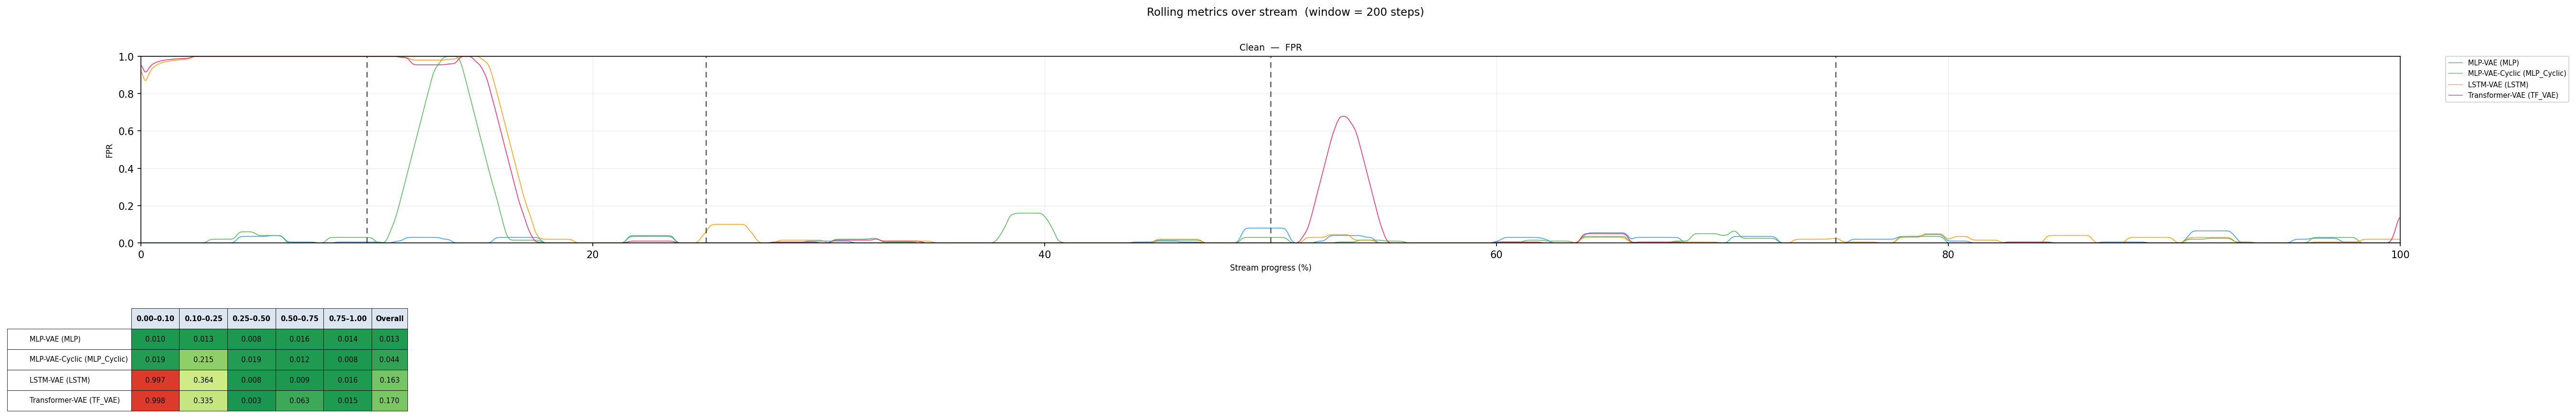

Full-scale dataset:


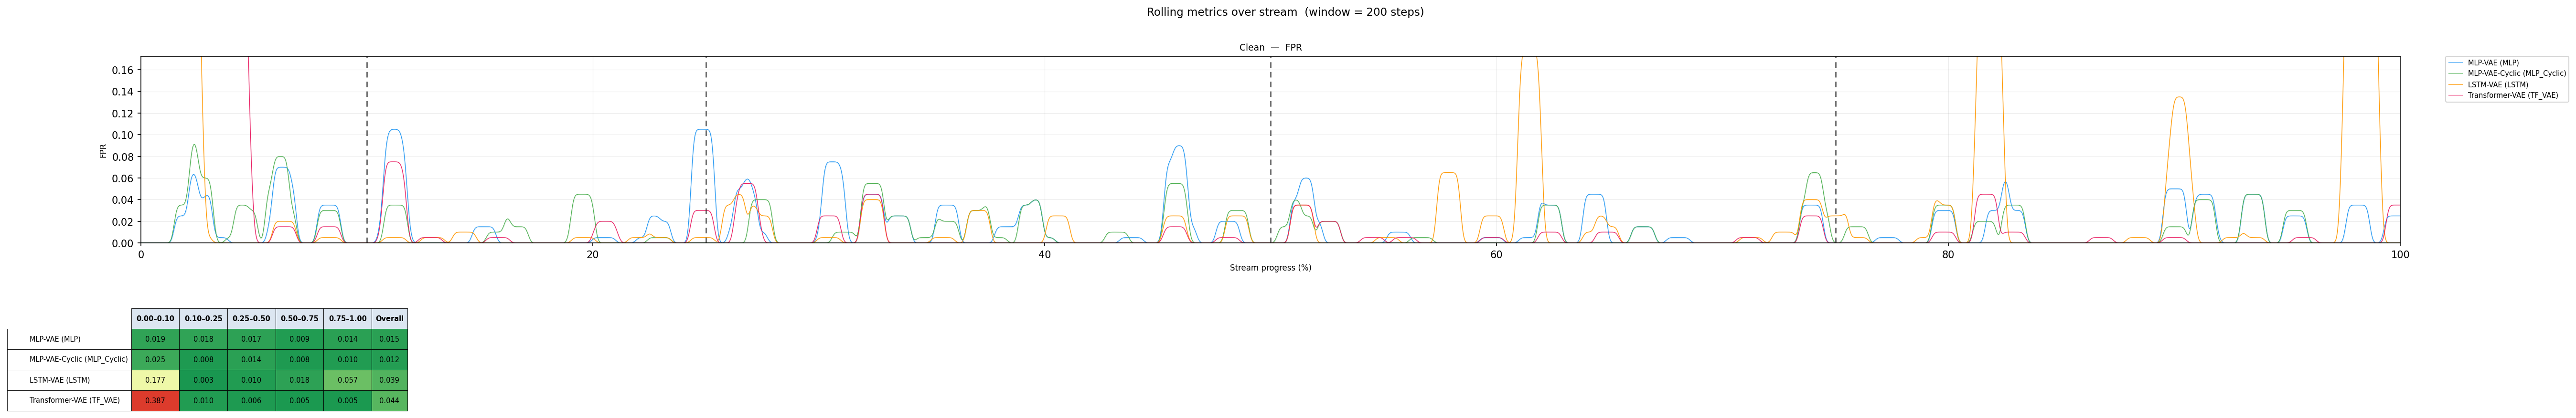

In [8]:
!python scripts/plot_fpr_over_time.py {MINI_OUTPUT_DIR}
!python scripts/plot_fpr_over_time.py {FULL_OUTPUT_DIR}
!python scripts/plot_fpr_over_time.py {MINI28_OUTPUT_DIR}

from IPython.display import Image, display

print("mini_28pct dataset:")
display(Image(filename=f"{MINI28_OUTPUT_DIR}/rolling_metrics.png"))

print("mini_50pct dataset:")
display(Image(filename=f"{MINI_OUTPUT_DIR}/rolling_metrics.png"))

print("Full-scale dataset:")
display(Image(filename=f"{FULL_OUTPUT_DIR}/rolling_metrics.png"))

## Scope of this testcase

This notebook doesn't introduce a new experiment — it runs `case01_clean_baseline_suite.yaml` twice (mini, then full-scale) and compares the results directly, to make an otherwise-invisible dependency explicit: case01's conclusions depend on running at full scale. Single seed on each side (real hardware nondeterminism applies — see case01's own seed-variance investigation), so differences beyond a rank flip shouldn't be over-interpreted from one seed per scale.

The mini dataset is Colab-portable; the full-scale split files also ship with the repo (`data/era5/full_scale/split/`), so this notebook works out of the box end to end, just slower for the full-scale half. See `DATA_LICENSE.md` for exact provenance of both.